# Sistema de Recomendação de Produtos - Questão 8

## Objetivo
Construir um sistema de recomendação baseado em **similaridade do cosseno** para identificar os 5 produtos mais similares ao *GPS Garmin Vortex Maré Drift* (`id_product = 27`), com base no comportamento de compra dos clientes.

## Metodologia
- Construção de uma **matriz binária Usuário-Item** (cliente x produto)
- Cálculo da **similaridade do cosseno** entre os vetores de produtos
- Ranking dos produtos mais similares ao produto de referência

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Carregamento dos Dados

In [2]:
df = pd.read_csv('../datasets/vendas_2023_2024.csv')

df['sale_date'] = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True)

print(f"Dataset carregado: {df.shape[0]} registros")
print(f"Clientes unicos: {df['id_client'].nunique()}")
print(f"Produtos unicos: {df['id_product'].nunique()}")
df.head()

Dataset carregado: 9895 registros
Clientes unicos: 49
Produtos unicos: 150


,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


## 2. Construção da Matriz Usuário-Item

A matriz binária indica se um cliente comprou (1) ou não comprou (0) determinado produto, independentemente da quantidade ou frequência de compra.

In [3]:
matriz_usuario_item = pd.crosstab(df['id_client'], df['id_product'])

matriz_usuario_item = matriz_usuario_item.clip(upper=1)

print(f"Dimensoes da matriz Usuario-Item: {matriz_usuario_item.shape}")
print(f"Clientes (linhas): {matriz_usuario_item.shape[0]}")
print(f"Produtos (colunas): {matriz_usuario_item.shape[1]}")
print(f"\nDensidade da matriz: {(matriz_usuario_item.values.sum() / (matriz_usuario_item.shape[0] * matriz_usuario_item.shape[1])) * 100:.2f}%")
print(f"\nPrimeiras 5 linhas e 8 colunas:")
matriz_usuario_item.iloc[:5, :8]

Dimensoes da matriz Usuario-Item: (49, 150)
Clientes (linhas): 49
Produtos (colunas): 150

Densidade da matriz: 73.65%

Primeiras 5 linhas e 8 colunas:


id_product,1,2,3,4,5,6,7,8
id_client,,,,,,,,
1,1,0,1,1,1,1,0,0
2,0,1,1,0,1,1,1,1
3,1,1,1,1,1,1,1,0
4,1,1,0,1,1,0,1,0
5,1,1,0,1,1,1,1,1


## 3. Cálculo da Similaridade do Cosseno

Transpomos a matriz para que cada **linha represente um produto** e cada **coluna represente um cliente**. A similaridade do cosseno é então calculada entre todos os pares de produtos.

In [4]:
matriz_item_usuario = matriz_usuario_item.T

print(f"Matriz transposta (Item-Usuario): {matriz_item_usuario.shape}")
print(f"Cada linha representa um produto com {matriz_item_usuario.shape[1]} dimensoes (clientes)")

similaridade = cosine_similarity(matriz_item_usuario)

df_similaridade = pd.DataFrame(
    similaridade,
    index=matriz_item_usuario.index,
    columns=matriz_item_usuario.index
)

print(f"\nMatriz de similaridade: {df_similaridade.shape}")
print(f"\nAmostra (5x5):")
df_similaridade.iloc[:5, :5]

Matriz transposta (Item-Usuario): (150, 49)
Cada linha representa um produto com 49 dimensoes (clientes)

Matriz de similaridade: (150, 150)

Amostra (5x5):


id_product,1,2,3,4,5
id_product,,,,,
1,1.000000,0.775058,0.737865,0.810191,0.748331
2,0.775058,1.000000,0.704295,0.757865,0.714286
3,0.737865,0.704295,1.000000,0.800641,0.704295
4,0.810191,0.757865,0.800641,1.000000,0.757865
5,0.748331,0.714286,0.704295,0.757865,1.000000


## 4. Top 5 Produtos Similares ao GPS Garmin Vortex Maré Drift (id_product = 27)

In [5]:
produto_referencia = 27

similaridades_produto = df_similaridade[produto_referencia].drop(produto_referencia)

top5 = similaridades_produto.sort_values(ascending=False).head(5)

print("=" * 60)
print(f"TOP 5 PRODUTOS SIMILARES AO PRODUTO {produto_referencia}")
print(f"(GPS Garmin Vortex Mare Drift)")
print("=" * 60)

for rank, (id_prod, sim) in enumerate(top5.items(), 1):
    print(f"  {rank}. id_product = {id_prod:>3d}  |  Similaridade = {sim:.4f}")

print(f"\nProduto mais similar: id_product = {top5.index[0]}")

TOP 5 PRODUTOS SIMILARES AO PRODUTO 27
(GPS Garmin Vortex Mare Drift)
  1. id_product =  94  |  Similaridade = 0.8696
  2. id_product =  11  |  Similaridade = 0.8680
  3. id_product =  35  |  Similaridade = 0.8539
  4. id_product =   1  |  Similaridade = 0.8500
  5. id_product = 115  |  Similaridade = 0.8500

Produto mais similar: id_product = 94


## 5. Validação (Questão 8.2)

In [6]:
print("=" * 60)
print("VALIDACAO - QUESTAO 8.2")
print("=" * 60)
print(f"\nProduto de referencia: id_product = {produto_referencia}")
print(f"Produto mais similar (1o do ranking): id_product = {top5.index[0]}")
print(f"Similaridade do cosseno: {top5.values[0]:.4f}")

VALIDACAO - QUESTAO 8.2

Produto de referencia: id_product = 27
Produto mais similar (1o do ranking): id_product = 94
Similaridade do cosseno: 0.8696


## 6. Visualização: Top 5 Produtos Similares

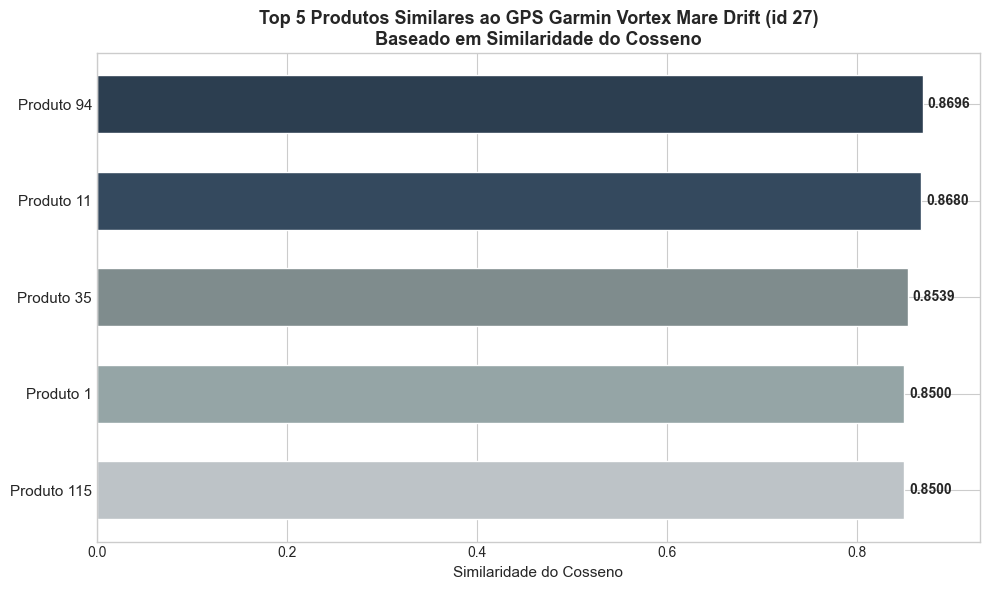

Grafico salvo em: ../outputs/graficos/08_recomendacao_top5.png


In [7]:
os.makedirs('../outputs/graficos', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))

produtos_labels = [f"Produto {id_p}" for id_p in top5.index]
cores = ['#2c3e50', '#34495e', '#7f8c8d', '#95a5a6', '#bdc3c7']

barras = ax.barh(range(len(top5)), top5.values, color=cores, edgecolor='white', height=0.6)

ax.set_yticks(range(len(top5)))
ax.set_yticklabels(produtos_labels, fontsize=11)
ax.set_xlabel('Similaridade do Cosseno', fontsize=11)
ax.set_title('Top 5 Produtos Similares ao GPS Garmin Vortex Mare Drift (id 27)\nBaseado em Similaridade do Cosseno', fontsize=13, fontweight='bold')

for i, (val, barra) in enumerate(zip(top5.values, barras)):
    ax.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, max(top5.values) + 0.06)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/graficos/08_recomendacao_top5.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo em: ../outputs/graficos/08_recomendacao_top5.png")

## 7. Interpretação dos Resultados (Questão 8.3)

### A. Como a matriz foi construída

Foi construída uma **matriz binária** onde as linhas representam clientes e as colunas representam produtos. O valor 1 indica que o cliente realizou pelo menos uma compra daquele produto; o valor 0 indica ausência de compra. A quantidade adquirida foi desconsiderada — apenas a **presença ou ausência** de compra é relevante para este modelo.

### B. O que a similaridade do cosseno representa neste contexto

A similaridade do cosseno mede o **ângulo entre dois vetores de produtos no espaço de clientes**. Dois produtos com alta similaridade significa que tendem a ser adquiridos pelo **mesmo conjunto de clientes**. Um valor igual a 1 indica padrões de compra idênticos; um valor igual a 0 indica nenhuma sobreposição. Esta métrica é particularmente adequada para dados binários esparsos, pois é invariante à magnitude dos vetores.

### C. Limitações do modelo

- Considera apenas a **presença ou ausência** de compra, ignorando quantidade e frequência. Um cliente que comprou 100 unidades de um produto é tratado da mesma forma que um cliente que comprou 1 unidade.
- **Problema de cold start:** produtos novos ou com poucas compras terão vetores esparsos, resultando em similaridades pouco confiáveis.
- Não considera **padrões temporais** (sazonalidade, tendências) nem **fatores contextuais** (categoria do produto, faixa de preço, região do cliente).
- A qualidade das recomendações depende diretamente do volume e diversidade do histórico de compras disponível.

In [8]:
print("=" * 60)
print("RESUMO FINAL")
print("=" * 60)
print(f"Produto de referencia: GPS Garmin Vortex Mare Drift (id 27)")
print(f"Metodo: Similaridade do Cosseno sobre matriz binaria")
print(f"Dimensoes da matriz: {matriz_usuario_item.shape[0]} clientes x {matriz_usuario_item.shape[1]} produtos")
print(f"\nTop 5 produtos recomendados:")
for rank, (id_prod, sim) in enumerate(top5.items(), 1):
    print(f"  {rank}. id_product = {id_prod} (similaridade: {sim:.4f})")

RESUMO FINAL
Produto de referencia: GPS Garmin Vortex Mare Drift (id 27)
Metodo: Similaridade do Cosseno sobre matriz binaria
Dimensoes da matriz: 49 clientes x 150 produtos

Top 5 produtos recomendados:
  1. id_product = 94 (similaridade: 0.8696)
  2. id_product = 11 (similaridade: 0.8680)
  3. id_product = 35 (similaridade: 0.8539)
  4. id_product = 1 (similaridade: 0.8500)
  5. id_product = 115 (similaridade: 0.8500)
